# 01 — TF-IDF + Naive Bayes

**Goal:** Train a Multinomial Naive Bayes classifier on TF-IDF features extracted from cleaned lyrics, then evaluate on the held-out test set.

**Depends on:** `data/train.csv` and `data/test.csv` produced by `00_preprocessing.ipynb`.

## 1. Imports and setup

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR     = os.path.join(REPO_ROOT, 'data')

## 2. Load train / test splits

In [16]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

X_train, y_train = train_df['lyrics_clean'], train_df['valence_label']
X_test,  y_test  = test_df['lyrics_clean'],  test_df['valence_label']

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 22,233  |  Test: 5,559


## 3. TF-IDF vectorisation

In [17]:
# TODO: tune max_features, ngram_range, min_df
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

## 4. Train Multinomial Naive Bayes

In [18]:
# TODO: tune alpha (smoothing parameter)
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', MultinomialNB(alpha=0.1))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5. Evaluate on test set

In [19]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Low (0)', 'High (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

              precision    recall  f1-score   support

     Low (0)       0.59      0.59      0.59      2490
    High (1)       0.66      0.66      0.66      3069

    accuracy                           0.63      5559
   macro avg       0.62      0.62      0.62      5559
weighted avg       0.63      0.63      0.63      5559

ROC-AUC: 0.6655


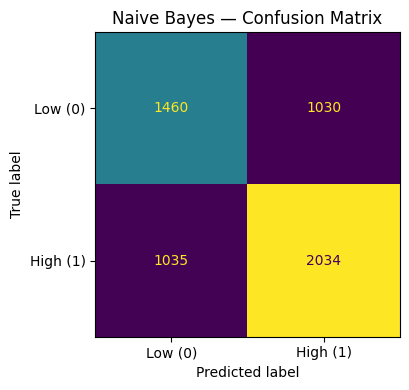

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Low (0)', 'High (1)'],
    colorbar=False, ax=ax
)
ax.set_title('Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'nb_confusion_matrix.png'), dpi=120)
plt.show()

## 6. Most informative features (optional)

In [21]:
# TODO: inspect top TF-IDF tokens associated with each class
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
log_probs = pipeline.named_steps['clf'].feature_log_prob_
top_n = 20

for cls_idx, cls_name in enumerate(['Low (0)', 'High (1)']):
    top_indices = np.argsort(log_probs[cls_idx])[-top_n:][::-1]
    print(f'\nTop {top_n} features for class {cls_name}:')
    print([feature_names[i] for i in top_indices])


Top 20 features for class Low (0):
['know', 'time', 'come', 'like', 'heart', 'life', 'away', 'go', 'feel', 'leave', 'live', 'want', 'dream', 'world', 'think', 'cause', 'fall', 'tell', 'need', 'eye']

Top 20 features for class High (1):
['know', 'like', 'time', 'come', 'yeah', 'go', 'heart', 'baby', 'cause', 'feel', 'want', 'away', 'life', 'tell', 'right', 'leave', 'think', 'gonna', 'live', 'night']


## 7. Save predictions for evaluation notebook

In [22]:
preds_df = pd.DataFrame({
    'valence_label': y_test.values,
    'y_pred':        y_pred,
    'y_proba':       y_proba,
})
out_path = os.path.join(DATA_DIR, 'nb_preds.csv')
preds_df.to_csv(out_path, index=False)
print(f'Saved {len(preds_df):,} rows → {out_path}')

Saved 5,559 rows → /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/nb_preds.csv
